# m/z 예측: 분자식에서 질량분석 신호 예측하기

질량분석기에서 화합물이 어떤 m/z 값으로 관측되는지 예측하는 방법을 다룹니다.

## 이 노트북에서 배우는 것
1. Monoisotopic mass — 분자식에서 정확한 질량 계산
2. Adduct 예측 — ESI에서 실제로 관측되는 이온 형태
3. 동위원소 패턴 — 이론 패턴 계산 및 시각화
4. 실측 스펙트럼에서 검증 — 예측 m/z가 실제로 있는지 확인

---

## 0. 환경 설정

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl


### Library Import 및 기본 설정

- 수치 계산(NumPy), 표 정리(Pandas), 시각화(Matplotlib) 라이브러리를 import합니다.
- 그래프 크기와 폰트 크기를 전체 노트북에 일괄 적용하여 일관된 시각화를 보장합니다.
- Warning 메시지를 숨겨 출력을 깔끔하게 유지합니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('준비 완료.')

---
## 1. Monoisotopic Mass 계산

화합물의 **분자식**을 알면, 각 원소의 **가장 풍부한 동위원소 질량**을 합산하여 정확한 질량을 구합니다.

| 원소 | 동위원소 | 정밀 질량 (Da) | 자연 존재비 |
|------|---------|---------------|------------|
| C | 12C | 12.000000 | 98.93% |
| H | 1H | 1.007940 | 99.99% |
| N | 14N | 14.003074 | 99.63% |
| O | 16O | 15.994915 | 99.76% |
| Cl | 35Cl | 34.968853 | 75.76% |

예: TNT (C7H5N3O6)
$$M = 7 \times 12.000000 + 5 \times 1.007940 + 3 \times 14.003074 + 6 \times 15.994915 = 227.01784$$

In [ ]:
# 원소별 monoisotopic mass (IUPAC 2016)
ATOMIC_MASS = {
    'H':  1.007825,    'C': 12.000000,   'N': 14.003074,
    'O': 15.994915,   'S': 31.972071,   'P': 30.973762,
    'F': 18.998403,   'Cl': 34.968853,  'Br': 78.918338,
    'I': 126.904473,  'Na': 22.989769,  'K': 39.098301,
}

def parse_formula(formula):
    """분자식 문자열 -> {원소: 개수} 딕셔너리
    예: 'C7H5N3O6' -> {'C': 7, 'H': 5, 'N': 3, 'O': 6}
    """
    import re
    elements = {}
    for match in re.finditer(r'([A-Z][a-z]?)(\d*)', formula):
        symbol = match.group(1)
        count = int(match.group(2)) if match.group(2) else 1
        if symbol:  # 빈 매치 무시
            elements[symbol] = elements.get(symbol, 0) + count
    return elements

def monoisotopic_mass(formula):
    """분자식 -> monoisotopic mass (Da)"""
    elements = parse_formula(formula)
    mass = 0.0
    for symbol, count in elements.items():
        if symbol not in ATOMIC_MASS:
            raise ValueError(f'Unknown element: {symbol}')
        mass += ATOMIC_MASS[symbol] * count
    return mass

# 폭발물 화합물들의 정확 질량 계산
compounds = {
    'TNT':      'C7H5N3O6',
    'RDX':      'C3H6N6O6',
    'HMX':      'C4H8N8O8',
    '2,4-DNT':  'C7H6N2O4',
    'Tetryl':   'C7H5N5O8',
    '4-Am-DNT': 'C7H7N3O4',
    '2,6-DNT':  'C7H6N2O4',
}

print(f'{"Name":12s} {"Formula":15s} {"MW (Da)":>12s}')
print('-' * 42)
for name, formula in compounds.items():
    mw = monoisotopic_mass(formula)
    print(f'{name:12s} {formula:15s} {mw:12.4f}')

---
## 2. Adduct란?

질량분석기에서 분자는 **중성 상태 그대로** 검출되지 않습니다.  
ESI(Electrospray Ionization)에서는 분자가 이온화되면서 **proton, Na, K 등과 결합**합니다.

```
중성 분자 (MW)  →  [M + H]+    (proton 결합, +1 전하)
                →  [M + Na]+   (sodium 결합, +1 전하)
                →  [M - H]-    (proton 손실, -1 전하)
```

따라서 **하나의 화합물이 여러 m/z 값**으로 동시에 나타납니다.

### m/z 계산 공식

$$m/z = \frac{MW + \Delta m}{|z|}$$

- $MW$: 중성 monoisotopic mass
- $\Delta m$: adduct에 의한 질량 변화
- $z$: 전하 수

In [ ]:
# 정밀 질량 상수 (IUPAC 2016)
PROTON   = 1.00728     # H+
SODIUM   = 22.98922    # Na+
POTASSIUM = 38.96316   # K+
AMMONIUM = 18.03437    # NH4+
CHLORIDE = 34.96885    # Cl-
FORMATE  = 44.99820    # HCOO-
WATER    = 18.01056    # H2O
ELECTRON = 0.00055     # e-
ACETATE  = 59.01385    # CH3COO-

# Adduct 정의: (이름, 전하수, 질량 shift)
ADDUCTS = {
    'positive': [
        ('[M+H]+',       1,  PROTON),
        ('[M+Na]+',      1,  SODIUM - ELECTRON),
        ('[M+K]+',       1,  POTASSIUM - ELECTRON),
        ('[M+NH4]+',     1,  AMMONIUM),
        ('[M+2H]2+',     2,  2 * PROTON),
        ('[M+H-H2O]+',   1,  PROTON - WATER),
    ],
    'negative': [
        ('[M-H]-',       1,  -PROTON),
        ('[M+FA-H]-',    1,  FORMATE),
        ('[M+CH3COO]-',  1,  ACETATE),
        ('[M+Cl]-',      1,  CHLORIDE),
        ('[M-2H]2-',     2,  -2 * PROTON),
    ],
}

def predict_mz(mw, mode='both'):
    """MW -> 모든 adduct의 예상 m/z 계산"""
    results = []
    modes = []
    if mode in ('positive', 'both'):
        modes.append('positive')
    if mode in ('negative', 'both'):
        modes.append('negative')
    
    for m in modes:
        for name, charge, shift in ADDUCTS[m]:
            mz = (mw + shift) / abs(charge)
            results.append({
                'adduct': name,
                'mz': round(mz, 4),
                'charge': charge if m == 'positive' else -charge,
                'mode': m,
            })
    return results

def mz_to_mw(mz, adduct='[M+H]+'):
    """관측 m/z -> MW 역산"""
    for mode_adducts in ADDUCTS.values():
        for name, charge, shift in mode_adducts:
            if name == adduct:
                return round(mz * abs(charge) - shift, 4)
    return None

print('Adduct 예측 함수 정의 완료.')

### TNT의 Adduct m/z 예측

- TNT(C7H5N3O6)의 monoisotopic mass를 기반으로 가능한 모든 adduct의 m/z를 계산합니다.
- Positive/Negative mode 양쪽의 adduct를 동시에 예측하여 결과를 DataFrame으로 정리합니다.
- 실제 질량분석 실험 전에 어떤 m/z 값을 기대해야 하는지 사전 확인하는 단계입니다.

In [ ]:
# 예시: TNT의 모든 adduct m/z 예측
tnt_mw = monoisotopic_mass('C7H5N3O6')
tnt_adducts = predict_mz(tnt_mw, mode='both')

print(f'TNT (C7H5N3O6)  MW = {tnt_mw:.4f} Da')
print()
df_tnt = pd.DataFrame(tnt_adducts)
print(df_tnt.to_string(index=False))

### 전체 화합물 Adduct 비교표

- 분석 대상 모든 화합물에 대해 주요 adduct([M-H]-, [M+CH3COO]-, [M+H]+, [M+Na]+)의 m/z를 한눈에 비교합니다.
- 화합물 간 m/z 차이를 확인하여, 실제 스펙트럼에서 피크가 겹치는지(isobaric interference) 사전 점검합니다.
- 이 표는 이후 스펙트럼 해석에서 피크 동정의 기준점이 됩니다.

In [ ]:
# 모든 화합물의 주요 adduct 비교
print(f'{"Compound":12s} {"MW":>10s} {"[M-H]-":>10s} {"[M+CH3COO]-":>12s} {"[M+H]+":>10s} {"[M+Na]+":>10s}')
print('-' * 70)

for name, formula in compounds.items():
    mw = monoisotopic_mass(formula)
    preds = predict_mz(mw, mode='both')
    pred_dict = {p['adduct']: p['mz'] for p in preds}
    
    print(f'{name:12s} {mw:10.4f} '
          f'{pred_dict.get("[M-H]-", 0):10.4f} '
          f'{pred_dict.get("[M+CH3COO]-", 0):12.4f} '
          f'{pred_dict.get("[M+H]+", 0):10.4f} '
          f'{pred_dict.get("[M+Na]+", 0):10.4f}')

### Adduct 시각화

하나의 화합물이 **여러 m/z로 동시에 나타나는** 것을 시각적으로 확인합니다.  
이것이 질량분석 스펙트럼 해석에서 가장 기본이 되는 개념입니다.

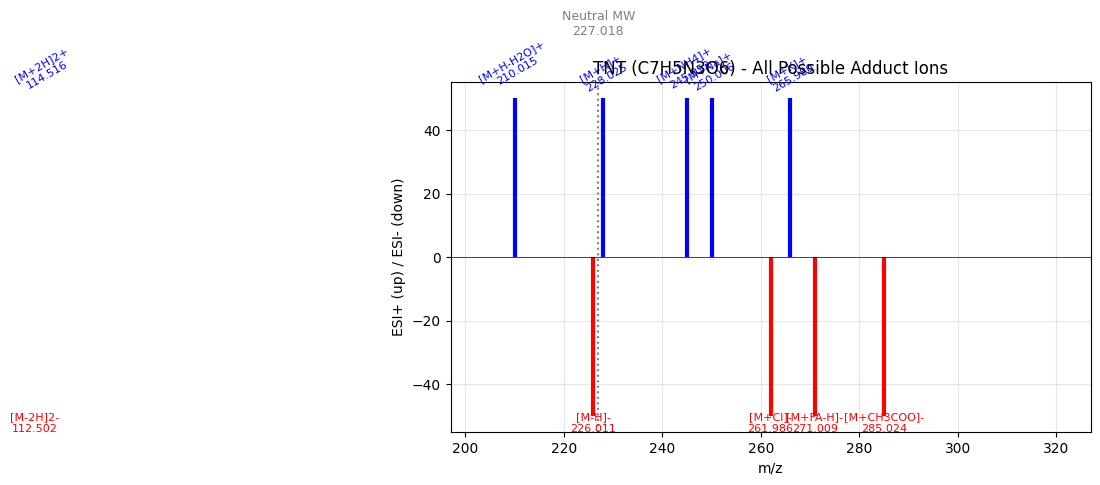

In [1]:
# TNT adduct 시각화
fig, ax = plt.subplots(figsize=(14, 5))

neg_adducts = [p for p in tnt_adducts if p['mode'] == 'negative']
pos_adducts = [p for p in tnt_adducts if p['mode'] == 'positive']

# Negative mode (아래)
for p in neg_adducts:
    ax.vlines(p['mz'], 0, -50, colors='red', linewidth=3)
    ax.text(p['mz'], -55, f"{p['adduct']}\n{p['mz']:.3f}",
           ha='center', fontsize=8, color='red')

# Positive mode (위)
for p in pos_adducts:
    ax.vlines(p['mz'], 0, 50, colors='blue', linewidth=3)
    ax.text(p['mz'], 52, f"{p['adduct']}\n{p['mz']:.3f}",
           ha='center', fontsize=8, color='blue', rotation=30)

# MW 표시
ax.axvline(tnt_mw, color='gray', linestyle=':', linewidth=1.5)
ax.text(tnt_mw, 70, f'Neutral MW\n{tnt_mw:.3f}', ha='center', fontsize=9, color='gray')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('m/z')
ax.set_ylabel('ESI+ (up) / ESI- (down)')
ax.set_title('TNT (C7H5N3O6) - All Possible Adduct Ions')
ax.set_xlim(tnt_mw - 30, tnt_mw + 100)
ax.set_ylim(-110, 110)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 역산: m/z -> MW

스펙트럼에서 피크를 발견했을 때, **어떤 adduct인지 가정**하면 원래 MW를 역산할 수 있습니다.

In [ ]:
# 역산 예시: m/z 226.009 (TNT의 [M-H]-)
observed_mz = 226.009

print(f'Observed m/z = {observed_mz:.3f}')
print(f'[M-H]- 가정 시 MW = {mz_to_mw(observed_mz, "[M-H]-"):.4f} Da')
print(f'[M+H]+ 가정 시 MW = {mz_to_mw(observed_mz, "[M+H]+"):.4f} Da')
print(f'[M+Na]+ 가정 시 MW = {mz_to_mw(observed_mz, "[M+Na]+"):.4f} Da')
print()
print(f'TNT 실제 MW = {monoisotopic_mass("C7H5N3O6"):.4f} Da')
print(f'→ [M-H]- 가정이 정답!')

---
## 3. 동위원소 패턴

자연계 원소는 여러 동위원소를 가집니다. 예를 들어 탄소:
- 12C: 98.93% (질량 12.000)
- 13C: 1.07% (질량 13.003)

분자가 탄소 7개를 포함하면, 일부 분자에서 13C가 1개 이상 포함될 확률이 있습니다.  
이것이 **M+1, M+2, M+3...** 피크로 나타납니다.

### 패턴의 의미
- 동위원소 패턴은 **분자식의 지문**입니다
- 같은 질량이라도 원소 조성이 다르면 패턴이 다름
- 특히 **Cl, Br, S** 포함 분자는 매우 특징적인 패턴

In [ ]:
import pyopenms as oms

def calculate_isotope_pattern(formula, charge=0, n_peaks=5):
    """pyopenms로 이론 동위원소 패턴 계산
    
    Returns: list of (mz, relative_intensity)
    """
    ef = oms.EmpiricalFormula(formula)
    iso = ef.getIsotopeDistribution(oms.CoarseIsotopePatternGenerator(n_peaks))
    
    peaks = []
    max_int = 0
    for peak in iso.getContainer():
        if peak.getIntensity() > max_int:
            max_int = peak.getIntensity()
    
    for peak in iso.getContainer():
        mz = peak.getMZ()
        rel_int = peak.getIntensity() / max_int * 100 if max_int > 0 else 0
        if charge != 0:
            mz = mz / abs(charge)
        peaks.append((mz, rel_int))
    
    return peaks

# TNT 동위원소 패턴
tnt_pattern = calculate_isotope_pattern('C7H5N3O6')

print('TNT (C7H5N3O6) Isotope Pattern:')
print(f'{"Peak":>6s} {"m/z":>10s} {"Rel.Int(%)":>10s}')
for i, (mz, rel) in enumerate(tnt_pattern):
    label = 'M' if i == 0 else f'M+{i}'
    print(f'{label:>6s} {mz:10.4f} {rel:10.1f}')

### 동위원소 패턴(Isotope Pattern) 비교 시각화

- 각 화합물의 이론적 동위원소 분포를 pyOpenMS로 계산하고 stick plot으로 시각화합니다.
- 동위원소 패턴은 분자 내 원소 조성(특히 Cl, Br, S 등)에 따라 고유한 지문 역할을 합니다.
- M, M+1, M+2 피크의 상대 강도 비율이 화합물 식별의 핵심 단서가 됩니다.

In [2]:
# 여러 화합물의 동위원소 패턴 비교
fig, axes = plt.subplots(len(compounds), 1, figsize=(12, 3 * len(compounds)))

for ax, (name, formula) in zip(axes, compounds.items()):
    pattern = calculate_isotope_pattern(formula, n_peaks=6)
    mzs = [p[0] for p in pattern]
    rels = [p[1] for p in pattern]
    
    ax.bar(range(len(mzs)), rels, color='steelblue', width=0.5)
    ax.set_xticks(range(len(mzs)))
    ax.set_xticklabels([f'M+{i}\n{mz:.3f}' if i > 0 else f'M\n{mz:.3f}' 
                        for i, mz in enumerate(mzs)], fontsize=8)
    ax.set_ylabel('Rel. Int (%)')
    ax.set_title(f'{name} ({formula}) - MW={monoisotopic_mass(formula):.4f}')
    ax.set_ylim(0, 115)
    
    # 수치 라벨
    for j, (mz, rel) in enumerate(pattern):
        if rel > 1:
            ax.text(j, rel + 2, f'{rel:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. 실측 스펙트럼에서 검증

이제 **이론 예측값을 실제 데이터와 대조**합니다.

1. mzML 데이터 로드
2. TIC 피크 시점의 mass spectrum 추출
3. 각 화합물의 예측 adduct m/z 위치에서 **실제 이온이 있는지** 확인
4. Mass accuracy (ppm) 계산

In [ ]:
import os, pyopenms as oms

exp = oms.MSExperiment()
oms.MzMLFile().load('echo-tof-colab/data/mzml/20260330_TOFMS.mzML', exp)
print(f'로드 완료: {exp.getNrSpectra()} spectra')

# TIC 최대 시점 스펙트럼
best_spec = max((s for s in exp if s.getMSLevel() == 1),
                key=lambda s: sum(s.get_peaks()[1]))
mz_data, int_data = best_spec.get_peaks()
print(f'스펙트럼: RT={best_spec.getRT()/60:.3f} min, {len(mz_data)} ions')


### 실측 스펙트럼에서 예측 Adduct 검증

- 앞서 계산한 예측 adduct m/z가 실제 측정 스펙트럼에 존재하는지 ppm tolerance 기반으로 검색합니다.
- Negative mode 데이터이므로 [M-H]-, [M+FA-H]-, [M+Cl]- 등 negative adduct를 중점 확인합니다.
- 피크가 검출되면 mass error(ppm)와 함께 보고하여 m/z 예측의 정확도를 정량적으로 평가합니다.

In [ ]:
# 각 화합물에 대해: 예측 adduct m/z가 실측 스펙트럼에 있는지?
# Negative mode 데이터이므로 negative adduct 위주로 확인

def find_peak(mz_arr, int_arr, target_mz, tol_ppm=20):
    """target_mz 주변에서 가장 가까운 피크 찾기"""
    tol_da = target_mz * tol_ppm * 1e-6
    mask = (mz_arr >= target_mz - tol_da) & (mz_arr <= target_mz + tol_da)
    if not np.any(mask):
        return None, None, None
    local_mz = mz_arr[mask]
    local_int = int_arr[mask]
    best_i = np.argmax(local_int)
    error_ppm = (local_mz[best_i] - target_mz) / target_mz * 1e6
    return local_mz[best_i], local_int[best_i], error_ppm

print(f'{"Compound":12s} {"Adduct":15s} {"Pred. m/z":>10s} {"Found m/z":>10s} '
      f'{"Error(ppm)":>10s} {"Intensity":>12s} {"Found?":>6s}')
print('-' * 85)

for name, formula in compounds.items():
    mw = monoisotopic_mass(formula)
    preds = predict_mz(mw, mode='negative')  # ESI- 데이터
    
    for p in preds:
        found_mz, found_int, err = find_peak(mz_data, int_data, p['mz'])
        if found_mz is not None:
            print(f'{name:12s} {p["adduct"]:15s} {p["mz"]:10.4f} {found_mz:10.4f} '
                  f'{err:10.1f} {found_int:12.1f} {"YES":>6s}')
        else:
            print(f'{name:12s} {p["adduct"]:15s} {p["mz"]:10.4f} {"---":>10s} '
                  f'{"---":>10s} {"---":>12s} {"---":>6s}')

### 스펙트럼 오버레이 시각화

- 실측 mass spectrum 위에 예측 adduct 위치를 수직선으로 표시하여 직관적으로 비교합니다.
- 각 adduct 유형별로 색상을 구분하여([M-H]- 빨강, [M+FA-H]- 주황 등) 어떤 adduct가 실제로 관측되는지 한눈에 파악합니다.
- 화합물별로 m/z 영역을 확대하여 피크 겹침 여부와 mass accuracy를 시각적으로 확인합니다.

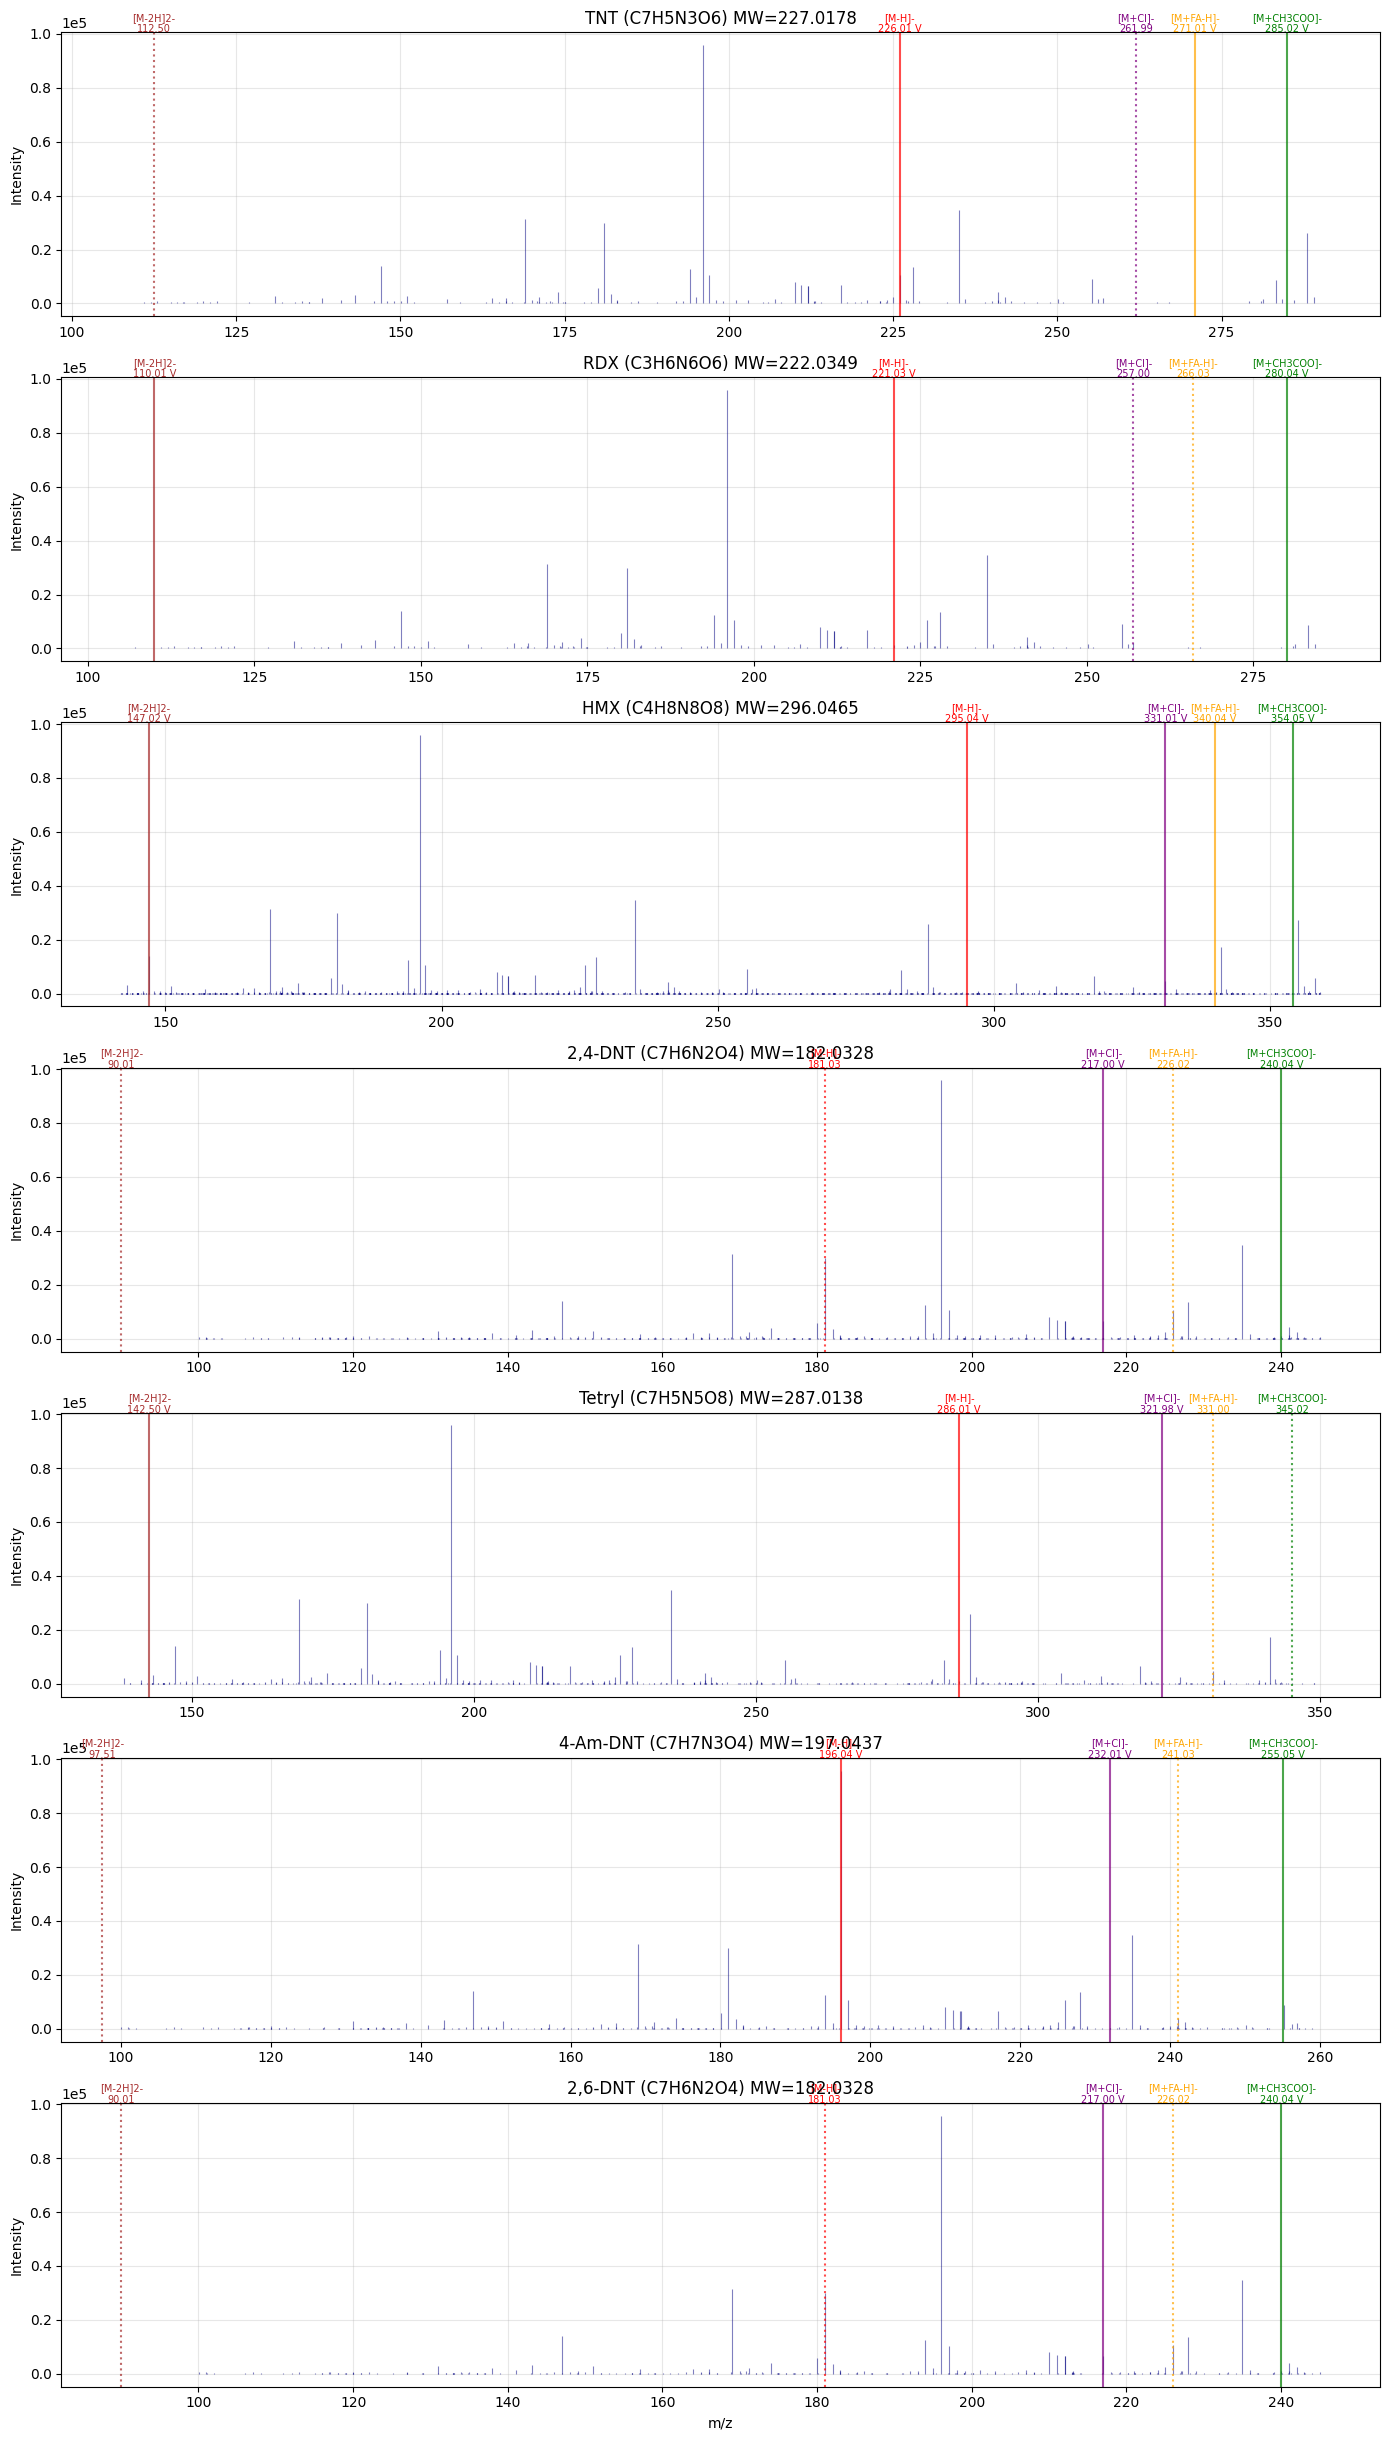

In [3]:
# 시각화: 실측 스펙트럼 + 예측 adduct 위치
# 화합물별로 m/z 영역 확대

fig, axes = plt.subplots(len(compounds), 1, figsize=(14, 3.5 * len(compounds)))

colors_adduct = {
    '[M-H]-': 'red', '[M+FA-H]-': 'orange',
    '[M+CH3COO]-': 'green', '[M+Cl]-': 'purple', '[M-2H]2-': 'brown'
}

for ax, (name, formula) in zip(axes, compounds.items()):
    mw = monoisotopic_mass(formula)
    preds = predict_mz(mw, mode='negative')
    
    # m/z 범위: 모든 adduct를 포함
    all_mz = [p['mz'] for p in preds]
    mz_min = min(all_mz) - 5
    mz_max = max(all_mz) + 5
    
    # 실측 스펙트럼
    mask = (mz_data >= mz_min) & (mz_data <= mz_max)
    ax.vlines(mz_data[mask], 0, int_data[mask], colors='navy', linewidth=0.8, alpha=0.5)
    
    # 예측 adduct 위치
    ymax = int_data[mask].max() if np.any(mask) and int_data[mask].max() > 0 else 100
    for p in preds:
        c = colors_adduct.get(p['adduct'], 'gray')
        found_mz, found_int, _ = find_peak(mz_data, int_data, p['mz'])
        style = '-' if found_mz else ':'
        ax.axvline(p['mz'], color=c, linestyle=style, alpha=0.7, linewidth=1.5)
        label = f"{p['adduct']}\n{p['mz']:.2f}"
        if found_mz:
            label += ' V'
        ax.text(p['mz'], ymax * 1.05, label, ha='center', fontsize=7, color=c)
    
    ax.set_title(f'{name} ({formula})  MW={mw:.4f}')
    ax.set_ylabel('Intensity')
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('m/z')
plt.tight_layout()
plt.show()

### 4-1. 동위원소 패턴 검증

예측 m/z에서 이온을 찾았다면, **동위원소 패턴이 이론과 일치하는지** 확인합니다.  
이것이 화합물 동정의 **가장 강력한 증거** 중 하나입니다.

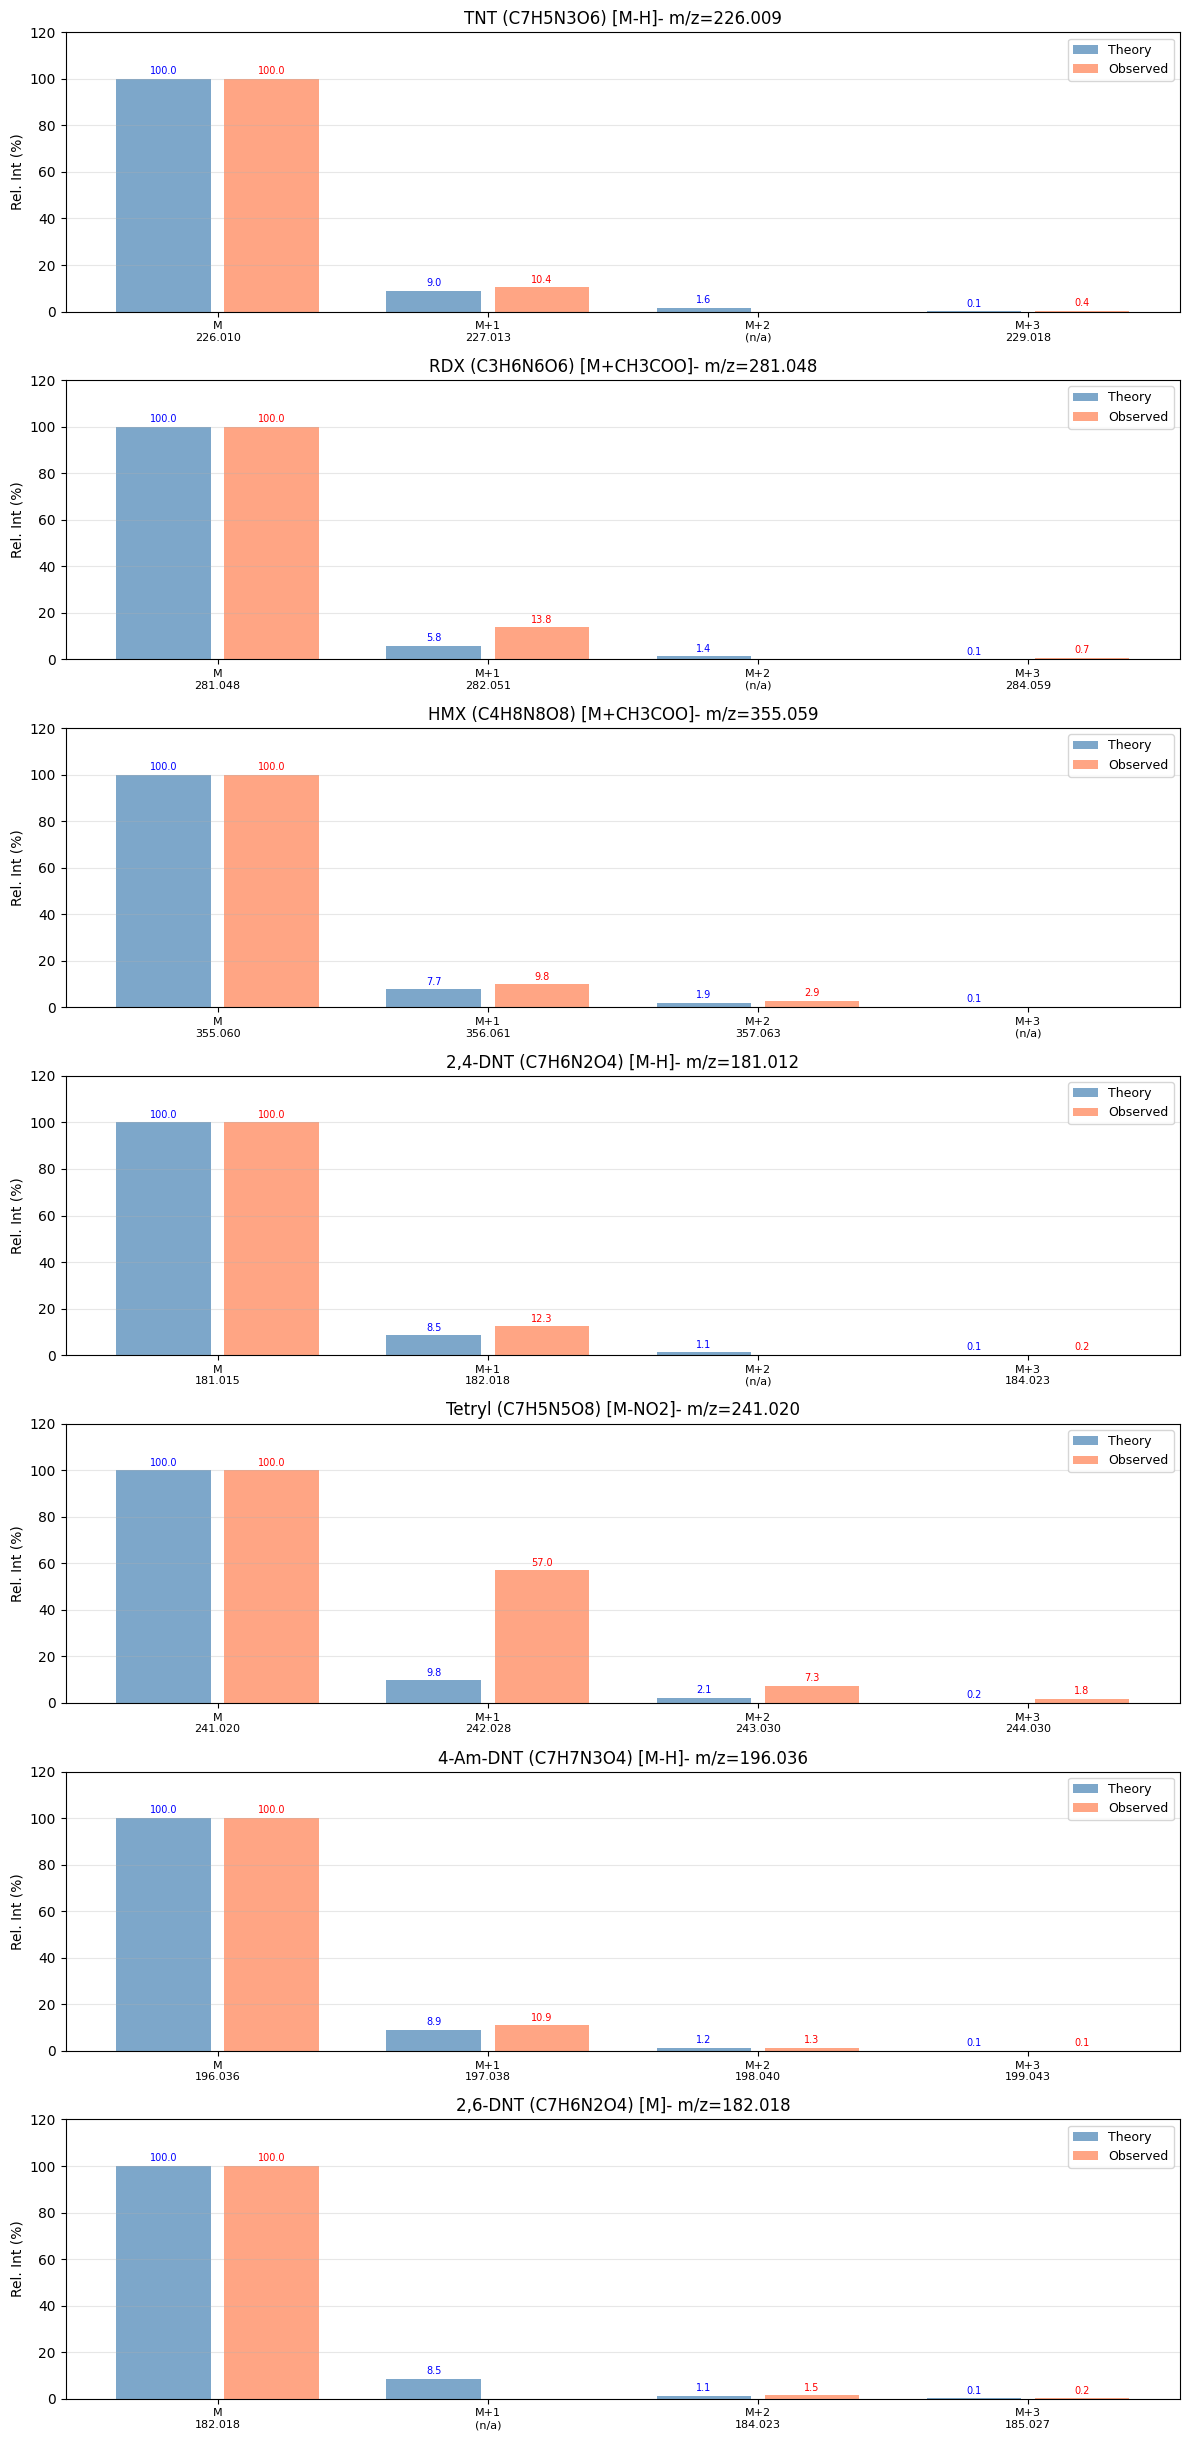

In [4]:
def compare_isotope_pattern(mz_data, int_data, formula, target_mz, tol_ppm=20, n_peaks=4):
    """이론 동위원소 패턴과 실측 비교"""
    theory = calculate_isotope_pattern(formula, n_peaks=n_peaks)
    
    results = []
    for i, (theo_mz, theo_rel) in enumerate(theory):
        # 동위원소 피크 간격: ~1.003 Da
        search_mz = target_mz + i * 1.00335
        found_mz, found_int, err = find_peak(mz_data, int_data, search_mz, tol_ppm)
        results.append({
            'peak': f'M+{i}' if i > 0 else 'M',
            'theo_mz': theo_mz,
            'theo_rel': theo_rel,
            'found_mz': found_mz,
            'found_int': found_int,
            'error_ppm': err,
        })
    
    # 실측 상대 강도 계산
    m0_int = results[0]['found_int'] if results[0]['found_int'] else 1
    for r in results:
        r['found_rel'] = (r['found_int'] / m0_int * 100) if r['found_int'] else 0
    
    return results

# 각 화합물의 [M-H]- 동위원소 패턴 검증
# (엑셀 MRM 데이터에서 사용된 adduct 기준)
adduct_map = {
    'TNT': ('[M-H]-', 226.009),
    'RDX': ('[M+CH3COO]-', 281.048),
    'HMX': ('[M+CH3COO]-', 355.059),
    '2,4-DNT': ('[M-H]-', 181.012),
    'Tetryl': ('[M-NO2]-', 241.020),
    '4-Am-DNT': ('[M-H]-', 196.036),
    '2,6-DNT': ('[M]-', 182.018),
}

fig, axes = plt.subplots(len(compounds), 1, figsize=(12, 3.5 * len(compounds)))

for ax, (name, formula) in zip(axes, compounds.items()):
    adduct, target_mz = adduct_map[name]
    results = compare_isotope_pattern(mz_data, int_data, formula, target_mz)
    
    x = np.arange(len(results))
    theo_rels = [r['theo_rel'] for r in results]
    found_rels = [r['found_rel'] for r in results]
    
    bars1 = ax.bar(x - 0.2, theo_rels, 0.35, color='steelblue', alpha=0.7, label='Theory')
    bars2 = ax.bar(x + 0.2, found_rels, 0.35, color='coral', alpha=0.7, label='Observed')
    
    ax.set_xticks(x)
    labels = []
    for r in results:
        if r['found_mz']:
            labels.append(f"{r['peak']}\n{r['found_mz']:.3f}")
        else:
            labels.append(f"{r['peak']}\n(not found)")
    ax.set_xticklabels(labels, fontsize=8)
    
    ax.set_ylabel('Relative Intensity (%)')
    ax.set_title(f'{name} ({formula}) {adduct} m/z={target_mz:.3f}')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 120)
    ax.grid(alpha=0.3, axis='y')
    
    # 수치 표시
    for j, r in enumerate(results):
        if r['found_rel'] > 0:
            ax.text(j + 0.2, r['found_rel'] + 2, f"{r['found_rel']:.1f}",
                   ha='center', fontsize=7, color='red')
        ax.text(j - 0.2, r['theo_rel'] + 2, f"{r['theo_rel']:.1f}",
               ha='center', fontsize=7, color='blue')

plt.tight_layout()
plt.show()

---
## Summary

| Step | 입력 | 출력 | 의미 |
|------|------|------|------|
| 분자식 -> MW | C7H5N3O6 | 227.0178 Da | 정확한 중성 질량 |
| MW -> Adduct m/z | 227.0178 | [M-H]- = 226.009 | 실제 관측되는 m/z |
| m/z -> 스펙트럼 검색 | 226.009 | Found at 226.0101 | 실존 확인 |
| 동위원소 패턴 | C7H5N3O6 | M:M+1:M+2 비율 | 구조 확인 |

### 핵심 포인트
- **하나의 화합물 = 여러 adduct = 여러 m/z 피크**
- Mass accuracy < 5 ppm이면 신뢰도 높음
- 동위원소 패턴 일치는 분자식 확인의 핵심 증거
- 다음 단계: **반응 부산물 MW 예측** (04 노트북)

---

⬅️ **Prev:** [Relative Ion Abundance](08%20Yield%20Composition.ipynb) | **Next:** [Formula Identification](10%20Formula%20Identification.ipynb) ➡️